## Experiment 1 — CPU vs CUDA vs PyTorch Vector Addition



**Objective:** This experiment compares the performance of vector addition implemented using CPU C++, a naive CUDA kernel, and PyTorch across increasing vector sizes from \(10^3\) to \(10^8\). For the CUDA implementation, the experiment separately measures Host-to-Device (H2D) transfer time, kernel execution time, Device-to-Host (D2H) transfer time, and total end-to-end latency. The goal is to observe when GPU execution begins to outperform CPU execution, understand how data-transfer and kernel-launch overhead affect smaller workloads, and analyze how performance scales as the vector size increases. 


## Implementation

In [1]:
!nvidia-smi

Sun Sep  6 21:22:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Installing ninja library for load_inline run

In [2]:
!pip install ninja

In [3]:
# import libraries
import torch # for pytorch
from torch.utils.cpp_extension import load_inline # for loading cuda/c++ code
import matplotlib.pyplot as plt # for plotting
import time # for cpu timing


In [4]:
n_array = [10**i for i in range(3, 9)]
print(n_array)

[1000, 10000, 100000, 1000000, 10000000, 100000000]


We need to pick 4 different timings:

- H2D Copy Time
- Kernel Exec Time
- D2H Copy Time
- Total end-to-end Time 

We have these types of kernel executions we need to look after: 

- CPU C++
- naive CUDA
- Pytorch

In [ ]:
# naive CUDA implementation
cpp_source = """

#include <torch/extension.h>

// add protoptype for the cuda kernel
torch::Tensor naive_add(torch::Tensor x, torch::Tensor y, int block_size);

"""

cuda_source = """

#include <torch/extension.h>

// naive CUDA implementation
__global__ void naive_add_kernel(const float* x, const float* y, float* z, int n){
    // get the thread id
    int tid = blockIdx.x * blockDim.x + threadIdx.x;

    // check if the thread id is less than the vector size
    if(tid < n){
        z[tid] = x[tid] + y[tid];
    }
}

// launcher of the cuda kernel comes after the kernel implementation is read
torch::Tensor naive_add(torch::Tensor x, torch::Tensor y, int block_size){

    // checks if the input tensors are on cuda

    TORCH_CHECK(x.device().is_cuda(), "x must be a CUDA tensor");
    TORCH_CHECK(y.device().is_cuda(), "y must be a CUDA tensor");
    TORCH_CHECK(x.numel() == y.numel(), "x and y must have the same number of elements");

    // get the vector size
    int n = x.numel();

    // allocate the output tensor
    torch::Tensor z = torch::zeros_like(x);

    // get the number of blocks 
    int num_blocks = (n + block_size - 1) / block_size;

    // launch the cuda kernel
    naive_add_kernel<<<num_blocks, block_size>>>(x.data_ptr<float>(), y.data_ptr<float>(), z.data_ptr<float>(), n);

    return z;
}


"""

module = load_inline(
    name="naive_add",
    cpp_sources=cpp_source, 
    cuda_sources=cuda_source,
    functions=["naive_add"],
    extra_cflags=["-O2"],
    verbose=True
)





In [6]:
# Pytorch implementation
def pytorch_add(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.add(x, y)



Creating a separate cpp file for CPU CPP implementation

added the results of execution in the `cpp_exec_time.csv`

In [12]:
# implement the naive cuda kernel call

def benchmark_naive_cuda(n):
    # create random tensors on CPU
    x_cpu = torch.randn(n, device='cpu')
    y_cpu = torch.randn(n, device='cpu')
    
    # create events for timing
    start_cuda = torch.cuda.Event(enable_timing=True)
    end_cuda = torch.cuda.Event(enable_timing=True) 

    # record start time
    start_cuda.record()
    
    # move tensors to GPU
    x_cuda = x_cpu.to('cuda')
    y_cuda = y_cpu.to('cuda')
    
    # record end time
    end_cuda.record()
    
    # synchronize to get the results
    torch.cuda.synchronize()
    cuda_time_h2d = start_cuda.elapsed_time(end_cuda)
    print(f"Naive CUDA H2D: {cuda_time_h2d} milliseconds")

    # warmup the cuda kernel
    for _ in range(10):
        z_cuda = module.naive_add(x_cuda, y_cuda, 256)

    torch.cuda.synchronize()
    
    # record start time
    start_cuda.record()
    
    # launch the cuda kernel
    z_cuda = module.naive_add(x_cuda, y_cuda, 256)
    
    # record end time
    end_cuda.record()
    
    # synchronize to get the results
    torch.cuda.synchronize()
    kernel_time = start_cuda.elapsed_time(end_cuda)
    print(f"Naive CUDA Kernel: {kernel_time} milliseconds")
    
    # record start time
    start_cuda.record()
    
    # move the result back to CPU
    z_cpu = z_cuda.to('cpu')
    
    # record end time
    end_cuda.record()
    
    # synchronize to get the results
    torch.cuda.synchronize()
    cuda_time_d2h = start_cuda.elapsed_time(end_cuda)
    print(f"Naive CUDA D2H: {cuda_time_d2h} milliseconds")
    
    

    return [cuda_time_h2d, kernel_time, cuda_time_d2h, cuda_time_h2d + kernel_time + cuda_time_d2h]
    

In [13]:
def benchmark_pytorch(n):
    # create random tensors on CPU
    x_cpu = torch.randn(n, device='cpu')
    y_cpu = torch.randn(n, device='cpu')
    
    # create events for timing
    start_cuda = torch.cuda.Event(enable_timing=True)
    end_cuda = torch.cuda.Event(enable_timing=True) 

    # record start time
    start_cuda.record()
    
    # move tensors to GPU
    x_cuda = x_cpu.to('cuda')
    y_cuda = y_cpu.to('cuda')
    
    # record end time
    end_cuda.record()
    
    # synchronize to get the results
    torch.cuda.synchronize()
    pytorch_h2d = start_cuda.elapsed_time(end_cuda)
    print(f"Pytorch Add H2D: {pytorch_h2d} milliseconds")

    # warmup the cuda kernel
    for _ in range(10):
        z_cuda = torch.add(x_cuda, y_cuda)

    torch.cuda.synchronize()
    
    # record start time
    start_cuda.record()
    
    # launch the cuda kernel
    z_cuda = torch.add(x_cuda, y_cuda)
    
    # record end time
    end_cuda.record()
    
    # synchronize to get the results
    torch.cuda.synchronize()
    kernel_time = start_cuda.elapsed_time(end_cuda)
    print(f"Pytorch Add Kernel: {kernel_time} milliseconds")
    
    # record start time
    start_cuda.record()
    
    # move the result back to CPU
    z_cpu = z_cuda.to('cpu')
    
    # record end time
    end_cuda.record()
    
    # synchronize to get the results
    torch.cuda.synchronize()
    pytorch_d2h = start_cuda.elapsed_time(end_cuda)
    print(f"Pytorch Add D2H: {pytorch_d2h} milliseconds")
    
    

    return [pytorch_h2d, kernel_time, pytorch_d2h, pytorch_h2d + kernel_time + pytorch_d2h]

In [15]:
h2d_times = []
kernel_times = []
d2h_times = []
total_times = []

for n in n_array:
    h2d_times.append(benchmark_naive_cuda(n)[0])
    kernel_times.append(benchmark_naive_cuda(n)[1])
    d2h_times.append(benchmark_naive_cuda(n)[2])
    total_times.append(benchmark_naive_cuda(n)[3])

h2d_pytorch = []
kernel_pytorch = []
d2h_pytorch = []
total_pytorch = []

for n in n_array:
    h2d_pytorch.append(benchmark_pytorch(n)[0])
    kernel_pytorch.append(benchmark_pytorch(n)[1])
    d2h_pytorch.append(benchmark_pytorch(n)[2])
    total_pytorch.append(benchmark_pytorch(n)[3])


Naive CUDA H2D: 0.41071999073028564 milliseconds
Naive CUDA Kernel: 0.10316800326108932 milliseconds
Naive CUDA D2H: 0.1531199961900711 milliseconds
Naive CUDA H2D: 0.19094400107860565 milliseconds
Naive CUDA Kernel: 0.11670400202274323 milliseconds
Naive CUDA D2H: 0.343423992395401 milliseconds
Naive CUDA H2D: 0.20160000026226044 milliseconds
Naive CUDA Kernel: 0.05049600079655647 milliseconds
Naive CUDA D2H: 0.05158400163054466 milliseconds
Naive CUDA H2D: 0.06998399645090103 milliseconds
Naive CUDA Kernel: 0.03519999980926514 milliseconds
Naive CUDA D2H: 0.049375999718904495 milliseconds
Naive CUDA H2D: 0.14265599846839905 milliseconds
Naive CUDA Kernel: 0.03686400130391121 milliseconds
Naive CUDA D2H: 0.06486400216817856 milliseconds
Naive CUDA H2D: 0.10822399705648422 milliseconds
Naive CUDA Kernel: 0.03478400036692619 milliseconds
Naive CUDA D2H: 0.0589120015501976 milliseconds
Naive CUDA H2D: 0.10489600151777267 milliseconds
Naive CUDA Kernel: 0.037248000502586365 milliseconds
N

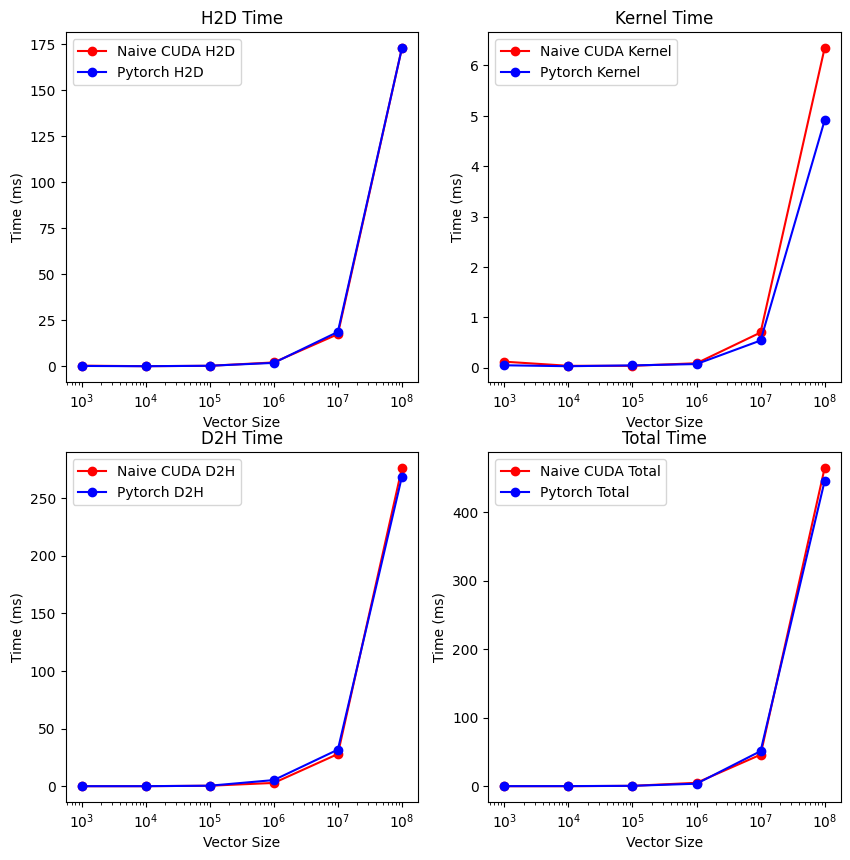

In [19]:
# plot the results
fig,axes = plt.subplots(2,2,figsize=(10, 10))
axes[0,0].plot(n_array, h2d_times, label='Naive CUDA H2D', color='red', marker='o')
axes[0,0].plot(n_array, h2d_pytorch, label='Pytorch H2D', color='blue', marker='o')
axes[0,0].set_title('H2D Time')
axes[0,0].set_xlabel('Vector Size')
axes[0,0].set_xscale('log')
axes[0,0].set_ylabel('Time (ms)')
axes[0,0].legend()

axes[0,1].plot(n_array, kernel_times, label='Naive CUDA Kernel', color='red', marker='o')
axes[0,1].plot(n_array, kernel_pytorch, label='Pytorch Kernel', color='blue', marker='o')
axes[0,1].set_title('Kernel Time')
axes[0,1].set_xlabel('Vector Size')
axes[0,1].set_xscale('log')
axes[0,1].set_ylabel('Time (ms)')
axes[0,1].legend()

axes[1,0].plot(n_array, d2h_times, label='Naive CUDA D2H', color='red', marker='o')
axes[1,0].plot(n_array, d2h_pytorch, label='Pytorch D2H', color='blue', marker='o')
axes[1,0].set_title('D2H Time')
axes[1,0].set_xlabel('Vector Size')
axes[1,0].set_xscale('log')
axes[1,0].set_ylabel('Time (ms)')
axes[1,0].legend()

axes[1,1].plot(n_array, total_times, label='Naive CUDA Total', color='red', marker='o')
axes[1,1].plot(n_array, total_pytorch, label='Pytorch Total', color='blue', marker='o')
axes[1,1].set_title('Total Time')
axes[1,1].set_xlabel('Vector Size')
axes[1,1].set_xscale('log')
axes[1,1].set_ylabel('Time (ms)')
axes[1,1].legend()

- For small vector sizes, both the naive CUDA and PyTorch implementations show very small execution times, with fixed launch and runtime overhead contributing significantly to the measurements.

- As the vector size increases, kernel execution time grows approximately with the amount of data processed, which is expected for vector addition because it is primarily memory-bandwidth bound. 

- PyTorch's torch.add becomes faster than the naive CUDA kernel at larger sizes, indicating better utilization of the GPU memory system. 

- However, the most significant result is that H2D and D2H transfer times are much larger than the kernel execution time. 

- At \(10^8\) elements, the kernel requires only a few milliseconds, while transferring the inputs and output requires hundreds of milliseconds. 

- Therefore, the end-to-end runtime is dominated by host-device communication rather than computation. This demonstrates why GPU workloads are most effective when data remains on the GPU across many operations instead of being transferred between CPU and GPU for every individual kernel.

An additional information I would like to add here is the CPU CPP and GPU Exec Time:

|        N |    CPU C++ | Naive CUDA kernel | PyTorch GPU kernel | Takeaway                                |
| -------: | ---------: | ----------------: | -----------------: | --------------------------------------- |
| \(10^3\) |      ~0 ms |          ~0.08 ms |      ~0.03–0.04 ms | CPU wins; GPU launch overhead dominates |
| \(10^4\) |   0.001 ms |          ~0.02 ms |           ~0.02 ms | CPU still faster                        |
| \(10^5\) |   0.021 ms |     ~0.02–0.03 ms |           ~0.02 ms | roughly crossover territory             |
| \(10^6\) |   0.613 ms |          ~0.08 ms |      ~0.05–0.06 ms | GPU clearly faster                      |
| \(10^7\) |   3.918 ms |           ~0.7 ms |            ~0.5 ms | GPU ~5–8× faster                        |
| \(10^8\) | 143.942 ms |           ~6.3 ms |            ~4.9 ms | GPU ~23–29× faster                      |


> A GPU kernel can be dramatically faster than a CPU implementation while the complete GPU workflow is still slower if every operation requires transferring large amounts of data between CPU and GPU.